# GCN vs GAT, from scratch — Cora node classification

This notebook implements **both** graph neural network layers from scratch in plain PyTorch — no
`torch_geometric.nn`, no `torch_scatter` — trains them on the same task, and compares them head to head:

| | GCN (Kipf & Welling, 2017) | GAT (Veličković et al., 2018) |
|---|---|---|
| Aggregation weight for neighbor *j* of node *i* | fixed: $\frac{1}{\sqrt{\deg(i)\deg(j)}}$, from graph structure alone | learned: softmax over an attention score computed from $Wh_i$ and $Wh_j$ |
| Depends on node features? | no — same weight regardless of what the nodes contain | yes — the whole point of the paper |
| Needs the full graph (Laplacian) at train time? | conceptually yes (spectral motivation), though the 1-hop form used here only needs the adjacency | no — attention is computed locally per edge, so it generalizes to unseen graphs/nodes (inductive) |
| Multi-head? | no | yes — stabilizes training, each head can specialize |
| Weights sum to 1 over a node's neighbors? | no (that's a quirk worth noticing below) | yes, by construction (softmax) |

We'll train both on **Cora** (2,708 papers, 1,433 bag-of-words features, 7 classes, citation edges) — the
exact benchmark both papers report on — and then visualize the one thing that actually differs: *how much
weight each model puts on each neighbor*.

> Only `torch_geometric` is used, and only for its `Planetoid` dataset loader (downloads Cora once, to
> `data/Cora/`). Every layer below — `GCNLayer`, `GATLayer` — is ~30 lines of raw `torch`.

## 0. Setup

In [ ]:
# Run once if you don't have these yet:
# %pip install torch torch_geometric matplotlib numpy

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

### Device

Cora is tiny (2,708 nodes) so CPU is plenty fast, but we'll try Apple's MPS backend first. Some of the
`scatter_reduce_` ops we rely on below aren't implemented on every MPS/PyTorch version, so we probe for
that specific op before committing to the device — better to fall back to CPU here than hit a cryptic
error three cells from now.

In [6]:
device = torch.device("cpu")
if torch.backends.mps.is_available():
    try:
        probe = torch.zeros(4, device="mps")
        probe.scatter_reduce_(0, torch.tensor([0, 1, 2, 3], device="mps"),
                              torch.ones(4, device="mps"), reduce="amax")
        device = torch.device("mps")
    except Exception as e:
        print(f"MPS present but scatter_reduce_(reduce='amax') isn't supported here ({e}); using CPU.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
print(f"Using device: {device}")

Using device: mps


## 1. Data: Cora citation network

Nodes are papers, edges are citations, node features are a 1,433-dim bag-of-words vector, and the label is
one of 7 research topics. The task is transductive node classification: the whole graph is visible at
train time, but only 140 nodes (20 per class) have labels available for the loss.

In [7]:
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T

dataset = Planetoid(root="data/Cora", name="Cora", transform=T.NormalizeFeatures())
data = dataset[0]

print(data)
print(f"nodes={data.num_nodes}  edges={data.num_edges}  features={dataset.num_node_features}  classes={dataset.num_classes}")
print(f"train/val/test nodes = {int(data.train_mask.sum())}/{int(data.val_mask.sum())}/{int(data.test_mask.sum())}")

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
nodes=2708  edges=10556  features=1433  classes=7
train/val/test nodes = 140/500/1000


## 2. Shared preprocessing

Both layers below operate on an `edge_index` of shape `[2, E]` (COO format: `edge_index[0]` = source node,
`edge_index[1]` = destination node) plus self-loops, so every node also aggregates its own features. GCN
additionally needs a precomputed per-edge normalization coefficient.

In [8]:
def add_self_loops(edge_index, num_nodes):
    device = edge_index.device
    mask = edge_index[0] != edge_index[1]
    edge_index = edge_index[:, mask]
    loop_index = torch.arange(num_nodes, device=device).unsqueeze(0).repeat(2, 1)
    return torch.cat([edge_index, loop_index], dim=1)


def compute_gcn_norm(edge_index, num_nodes):
    """norm(j -> i) = 1 / sqrt(deg(i) * deg(j)), the D^-1/2 A~ D^-1/2 coefficient from Kipf & Welling eq. 8."""
    row, col = edge_index
    deg = torch.zeros(num_nodes, device=edge_index.device)
    deg.index_add_(0, row, torch.ones_like(row, dtype=torch.float))
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0
    return deg_inv_sqrt[row] * deg_inv_sqrt[col]

### Scatter helpers

Message passing means: for every destination node, sum (or softmax-then-sum) messages coming in along its
edges. `index_add_` gives us scatter-sum for free; scatter-*max* (needed to stabilize GAT's softmax) isn't
directly exposed, but `scatter_reduce_(reduce="amax")` does it in one vectorized call — no Python loop over
2,708 nodes.

In [9]:
def scatter_add(src, index, num_nodes):
    """Sum src[e] into out[index[e]] for every edge e. src: [E, ...] -> out: [num_nodes, ...]"""
    shape = (num_nodes,) + tuple(src.shape[1:])
    out = torch.zeros(shape, dtype=src.dtype, device=src.device)
    out.index_add_(0, index, src)
    return out


def scatter_max_broadcast(src, index, num_nodes):
    """For every edge e, return the max of src over all edges sharing index[e] (i.e. per destination node)."""
    shape = (num_nodes,) + tuple(src.shape[1:])
    out = torch.full(shape, float("-inf"), dtype=src.dtype, device=src.device)
    idx = index
    for _ in range(src.dim() - 1):
        idx = idx.unsqueeze(-1)
    idx = idx.expand_as(src)
    out.scatter_reduce_(0, idx, src, reduce="amax", include_self=True)
    return out[index]

## 3. GCN layer, from scratch

$$H' = \hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} H W$$

where $\hat{A} = A + I$ (self-loops) and $\hat{D}$ is its degree matrix. Per-edge, this is just: linearly
transform every node's features, scale each neighbor's transformed features by the fixed `norm` coefficient,
and sum into the destination node.

In [10]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=bias)
        nn.init.xavier_uniform_(self.linear.weight)

    def forward(self, x, edge_index, norm, num_nodes):
        row, col = edge_index  # row = neighbor (source), col = destination
        h = self.linear(x)
        msg = h[row] * norm.unsqueeze(-1)
        return scatter_add(msg, col, num_nodes)


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.gc1 = GCNLayer(in_dim, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, norm, num_nodes):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.gc1(x, edge_index, norm, num_nodes))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.gc2(x, edge_index, norm, num_nodes)

## 4. GAT layer, from scratch

$$e_{ij} = \text{LeakyReLU}\big(a_{src}^\top W h_j + a_{dst}^\top W h_i\big), \qquad
\alpha_{ij} = \underset{j \in \mathcal{N}(i)}{\text{softmax}}(e_{ij})$$
$$h_i' = \big\Vert_{k=1}^{K} \sigma\Big(\sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(k)} W^{(k)} h_j\Big)$$

Same message-passing skeleton as GCN, but the per-edge weight `alpha` is no longer a structural constant —
it's computed from the (transformed) features of both endpoints, then softmax-normalized over each
destination node's incoming edges. That's the entire difference between the two papers, implemented.

We split the attention vector `a` into `att_src`/`att_dst` (applied to source/destination separately, then
added) — algebraically identical to the paper's single concatenated `a^T[Wh_i || Wh_j]`, but avoids
materializing an `[E, 2*out_dim]` tensor.

In [11]:
class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=1, concat=True, dropout=0.6, negative_slope=0.2):
        super().__init__()
        self.heads = heads
        self.out_dim = out_dim
        self.concat = concat
        self.dropout = dropout

        self.linear = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.att_src = nn.Parameter(torch.empty(heads, out_dim))
        self.att_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(heads * out_dim if concat else out_dim))
        self.leaky_relu = nn.LeakyReLU(negative_slope)

        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)

    def forward(self, x, edge_index, num_nodes, return_attention=False):
        row, col = edge_index  # row = neighbor j (source), col = destination i

        h = self.linear(x).view(num_nodes, self.heads, self.out_dim)
        h_row, h_col = h[row], h[col]

        e = self.leaky_relu(
            (h_row * self.att_src).sum(dim=-1) + (h_col * self.att_dst).sum(dim=-1)
        )  # [E, heads]

        # softmax over the neighbors of each destination node (numerically stabilized)
        e_max = scatter_max_broadcast(e, col, num_nodes)
        e = (e - e_max).exp()
        denom = scatter_add(e, col, num_nodes)[col] + 1e-16
        alpha = e / denom
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        out = scatter_add(h_row * alpha.unsqueeze(-1), col, num_nodes)  # [N, heads, out_dim]
        out = out.reshape(num_nodes, self.heads * self.out_dim) if self.concat else out.mean(dim=1)
        out = out + self.bias

        if return_attention:
            return out, (edge_index, alpha)
        return out


class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=8, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATLayer(in_dim, hidden_dim, heads=heads, concat=True, dropout=dropout)
        self.gat2 = GATLayer(hidden_dim * heads, out_dim, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index, num_nodes):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat1(x, edge_index, num_nodes))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.gat2(x, edge_index, num_nodes)

## 5. Training

Same optimizer family, same loop, same early-stopping-by-best-val-accuracy for both models — only the
hyperparameters differ, and only because each paper reports different ones for Cora (GAT uses a smaller
learning rate and heavier dropout to compensate for its larger parameter count from multi-head attention).

In [12]:
def accuracy(logits, y, mask):
    pred = logits[mask].argmax(dim=1)
    return (pred == y[mask]).float().mean().item()


def train_model(model, x, edge_index, y, train_mask, val_mask, test_mask, num_nodes,
                 norm=None, epochs=200, lr=0.01, weight_decay=5e-4, model_name="model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None

    def forward():
        return model(x, edge_index, norm, num_nodes) if norm is not None else model(x, edge_index, num_nodes)

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = forward()
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = forward()
            val_loss = F.cross_entropy(logits[val_mask], y[val_mask]).item()
            train_acc = accuracy(logits, y, train_mask)
            val_acc = accuracy(logits, y, val_mask)

        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % 20 == 0:
            print(f"[{model_name}] epoch {epoch:3d} | train_loss {loss.item():.4f} | "
                  f"val_loss {val_loss:.4f} | train_acc {train_acc:.3f} | val_acc {val_acc:.3f}")

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_acc = accuracy(forward(), y, test_mask)
    print(f"[{model_name}] best val_acc {best_val_acc:.3f} | test_acc {test_acc:.3f}")
    return history, test_acc

In [13]:
x = data.x.to(device)
y = data.y.to(device)
train_mask = data.train_mask.to(device)
val_mask = data.val_mask.to(device)
test_mask = data.test_mask.to(device)
num_nodes = data.num_nodes

edge_index_gcn = add_self_loops(data.edge_index.to(device), num_nodes)
gcn_norm = compute_gcn_norm(edge_index_gcn, num_nodes)

edge_index_gat = add_self_loops(data.edge_index.to(device), num_nodes)  # GAT paper also injects self-loops (sec. 2.1)

in_dim, out_dim = dataset.num_node_features, dataset.num_classes

In [14]:
torch.manual_seed(0)
gcn_model = GCN(in_dim, hidden_dim=16, out_dim=out_dim, dropout=0.5).to(device)
gcn_history, gcn_test_acc = train_model(
    gcn_model, x, edge_index_gcn, y, train_mask, val_mask, test_mask, num_nodes,
    norm=gcn_norm, epochs=200, lr=0.01, weight_decay=5e-4, model_name="GCN",
)

[GCN] epoch   1 | train_loss 1.9563 | val_loss 1.9393 | train_acc 0.143 | val_acc 0.122
[GCN] epoch  20 | train_loss 1.7749 | val_loss 1.8516 | train_acc 0.843 | val_acc 0.506
[GCN] epoch  40 | train_loss 1.4239 | val_loss 1.6520 | train_acc 0.936 | val_acc 0.712
[GCN] epoch  60 | train_loss 1.0574 | val_loss 1.3833 | train_acc 0.971 | val_acc 0.760
[GCN] epoch  80 | train_loss 0.7625 | val_loss 1.1793 | train_acc 0.986 | val_acc 0.768
[GCN] epoch 100 | train_loss 0.6383 | val_loss 1.0425 | train_acc 0.986 | val_acc 0.792
[GCN] epoch 120 | train_loss 0.5807 | val_loss 0.9645 | train_acc 0.986 | val_acc 0.782
[GCN] epoch 140 | train_loss 0.5395 | val_loss 0.9082 | train_acc 0.986 | val_acc 0.790
[GCN] epoch 160 | train_loss 0.4349 | val_loss 0.8627 | train_acc 0.986 | val_acc 0.788
[GCN] epoch 180 | train_loss 0.4479 | val_loss 0.8423 | train_acc 0.993 | val_acc 0.788
[GCN] epoch 200 | train_loss 0.3641 | val_loss 0.8051 | train_acc 0.993 | val_acc 0.796
[GCN] best val_acc 0.800 | test_

In [15]:
torch.manual_seed(0)
gat_model = GAT(in_dim, hidden_dim=8, out_dim=out_dim, heads=8, dropout=0.6).to(device)
gat_history, gat_test_acc = train_model(
    gat_model, x, edge_index_gat, y, train_mask, val_mask, test_mask, num_nodes,
    norm=None, epochs=200, lr=0.005, weight_decay=5e-4, model_name="GAT",
)

[GAT] epoch   1 | train_loss 1.9460 | val_loss 1.9389 | train_acc 0.286 | val_acc 0.272
[GAT] epoch  20 | train_loss 1.7970 | val_loss 1.8486 | train_acc 0.950 | val_acc 0.770
[GAT] epoch  40 | train_loss 1.4845 | val_loss 1.6639 | train_acc 0.950 | val_acc 0.814
[GAT] epoch  60 | train_loss 1.2778 | val_loss 1.4279 | train_acc 0.957 | val_acc 0.820
[GAT] epoch  80 | train_loss 1.0335 | val_loss 1.2454 | train_acc 0.971 | val_acc 0.808
[GAT] epoch 100 | train_loss 1.0249 | val_loss 1.0715 | train_acc 0.971 | val_acc 0.802
[GAT] epoch 120 | train_loss 0.7674 | val_loss 0.9800 | train_acc 0.979 | val_acc 0.792
[GAT] epoch 140 | train_loss 0.8538 | val_loss 0.9107 | train_acc 0.986 | val_acc 0.812
[GAT] epoch 160 | train_loss 0.8586 | val_loss 0.8867 | train_acc 0.986 | val_acc 0.808
[GAT] epoch 180 | train_loss 0.7398 | val_loss 0.8399 | train_acc 0.993 | val_acc 0.802
[GAT] epoch 200 | train_loss 0.7323 | val_loss 0.8202 | train_acc 0.993 | val_acc 0.810
[GAT] best val_acc 0.826 | test_

## 6. Results

Both should land around **80-83%** test accuracy on Cora (GCN) and **82-84%** (GAT) — matching the
published numbers, give or take a point from the random train/val split and init. GAT usually edges out
GCN by a small margin here; the gap widens on graphs where neighbor *relevance* varies more (e.g. noisier
or heterophilous graphs), which is exactly what the attention mechanism is built to exploit.

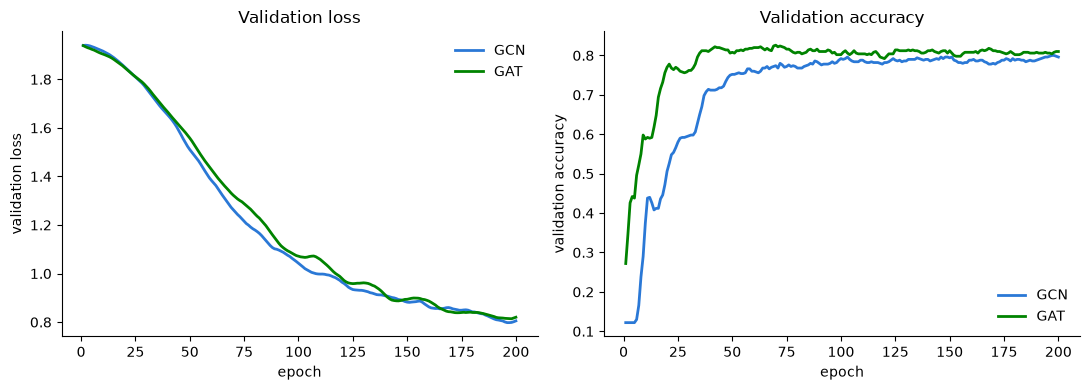

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(gcn_history["epoch"], gcn_history["val_loss"], color="#2a78d6", linewidth=2, label="GCN")
axes[0].plot(gat_history["epoch"], gat_history["val_loss"], color="#008300", linewidth=2, label="GAT")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation loss"); axes[0].set_title("Validation loss")
axes[0].legend(frameon=False); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(gcn_history["epoch"], gcn_history["val_acc"], color="#2a78d6", linewidth=2, label="GCN")
axes[1].plot(gat_history["epoch"], gat_history["val_acc"], color="#008300", linewidth=2, label="GAT")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation accuracy"); axes[1].set_title("Validation accuracy")
axes[1].legend(frameon=False); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

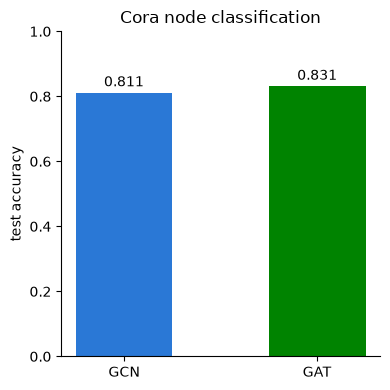

In [17]:
fig, ax = plt.subplots(figsize=(4, 4))
models, accs, colors = ["GCN", "GAT"], [gcn_test_acc, gat_test_acc], ["#2a78d6", "#008300"]
bars = ax.bar(models, accs, color=colors, width=0.5)
ax.set_ylim(0, 1); ax.set_ylabel("test accuracy"); ax.set_title("Cora node classification")
ax.spines[["top", "right"]].set_visible(False)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 7. What's actually different: look at the weights

Accuracy numbers hide the mechanism. Pick one node, look at the weight each model assigns to each of its
neighbors when aggregating: GCN's weights come purely from degree (structural, fixed before training even
starts); GAT's come from a learned function of the neighbors' *features*, re-normalized every forward pass.

In [18]:
def get_first_layer_attention(model, x, edge_index, num_nodes):
    model.eval()
    with torch.no_grad():
        _, (att_edge_index, att_alpha) = model.gat1(x, edge_index, num_nodes, return_attention=True)
    return att_edge_index, att_alpha  # att_alpha: [E, heads]


# pick a node with a handful of real (non-self-loop) neighbors, so the chart is legible
row0, col0 = data.edge_index
deg_count = torch.bincount(col0, minlength=num_nodes)
candidates = (deg_count >= 5).nonzero().flatten()
torch.manual_seed(1)
node_id = candidates[torch.randint(0, len(candidates), (1,))].item()
print(f"Inspecting node {node_id} (degree {deg_count[node_id].item()}, class {int(data.y[node_id])})")

Inspecting node 2227 (degree 6, class 5)


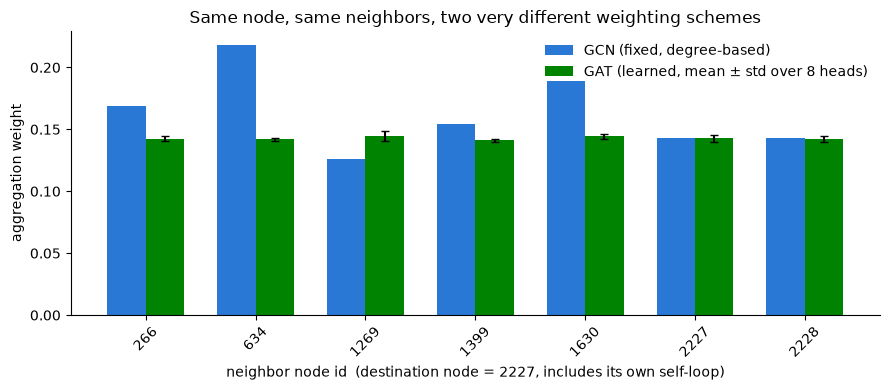

In [19]:
att_edge_index, att_alpha = get_first_layer_attention(gat_model, x, edge_index_gat, num_nodes)
gat_row, gat_col = att_edge_index
gat_mask = gat_col == node_id
gat_neighbor_ids = gat_row[gat_mask].cpu().numpy()
gat_neighbor_alpha = att_alpha[gat_mask].cpu().numpy()  # [num_neighbors, heads]

gcn_row, gcn_col = edge_index_gcn
gcn_mask = gcn_col == node_id
gcn_neighbor_ids = gcn_row[gcn_mask].cpu().numpy()
gcn_neighbor_w = gcn_norm[gcn_mask].cpu().numpy()

gat_order = np.argsort(gat_neighbor_ids)
gcn_order = np.argsort(gcn_neighbor_ids)
neighbor_ids = gat_neighbor_ids[gat_order]
assert (neighbor_ids == gcn_neighbor_ids[gcn_order]).all(), "GCN/GAT neighbor sets should match (same self-loop graph)"

gat_mean = gat_neighbor_alpha[gat_order].mean(axis=1)
gat_std = gat_neighbor_alpha[gat_order].std(axis=1)
gcn_w = gcn_neighbor_w[gcn_order]

x_pos, width = np.arange(len(neighbor_ids)), 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_pos - width / 2, gcn_w, width, color="#2a78d6", label="GCN (fixed, degree-based)")
ax.bar(x_pos + width / 2, gat_mean, width, yerr=gat_std, capsize=3,
       color="#008300", label="GAT (learned, mean \u00b1 std over 8 heads)")
ax.set_xticks(x_pos)
ax.set_xticklabels([str(n) for n in neighbor_ids], rotation=45)
ax.set_xlabel(f"neighbor node id  (destination node = {node_id}, includes its own self-loop)")
ax.set_ylabel("aggregation weight")
ax.set_title("Same node, same neighbors, two very different weighting schemes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Notice two things:

1. **GCN's bars barely vary** — they're set entirely by $1/\sqrt{\deg(i)\deg(j)}$, so neighbors with similar
   degree get similar weight no matter how (ir)relevant their features are to node $i$.
2. **GAT's bars vary a lot, and the error bars show the 8 heads don't even agree** — different heads have
   learned to attend to different neighbors, which is the multi-head mechanism doing exactly what the paper
   claims: each head can specialize in a different notion of "relevant neighbor."

That's the whole paper, in one bar chart.